# 1. ETL - Extract, Transform and Load


## 1.1 Library import


In [829]:
import pandas as pd

## 1.2 Data extraction

- CSV loading


In [830]:
url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"
url_2k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/2k.csv"
url_4k7 = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/4k7.csv"

raw_1k_csv = pd.read_fwf(url_1k, header=None, skip_blank_lines=False)
raw_2k_csv = pd.read_fwf(url_2k, header=None, skip_blank_lines=False)
raw_4k7_csv = pd.read_fwf(url_4k7, header=None, skip_blank_lines=False)


## 1.3 Raw data inspection

- File preview
- Shape inspection
- Sample count verification


In [831]:
preview = raw_1k_csv.head(20)
print(preview.to_string(index=False, header=False))


                                                  Model,MSO46B
                                      Channel,CH1,,Channel,CH2
                                                Label,,,Label,
                    Waveform Type,ANALOG,,Waveform Type,ANALOG
                          Digital Type,None,,Digital Type,None
                        Horizontal Units,s,,Horizontal Units,s
Sample Interval,8.00000000e-05,,Sample Interval,8.00000000e-05
                    Record Length,148144,,Record Length,148144
          Zero Index,23143.00000000,,Zero Index,23143.00000000
                            Vertical Units,V,,Vertical Units,V
                                                          ,,,,
                          ANALOG_Thumbnail,,,ANALOG_Thumbnail,
                            yOffset,0.000000,,yOffset,0.000000
                        yPosition,0.000000,,yPosition,0.180000
                                                           NaN
                                                      L

In [832]:
pd.DataFrame({
    "load": ["1k", "2k", "4k7"],
    "raw_shape": [raw_1k_csv.shape, raw_2k_csv.shape, raw_4k7_csv.shape],
})


,load,raw_shape
0,1k,"(148161, 1)"
1,2k,"(151089, 1)"
2,4k7,"(107745, 1)"


## 1.4 Column selection and dataset naming

- Column selection
- Dataset naming


In [833]:
# Carga de 1000 Ω
data_1k_load = pd.read_csv(url_1k, skiprows=17, usecols=[1, 2])
data_1k_load.columns = ["dac_volts", "shunt_volts"]
data_1k_load["sample"] = data_1k_load.index

# Carga de 2000 Ω
data_2k_load = pd.read_csv(url_2k, skiprows=17, usecols=[1, 2])
data_2k_load.columns = ["dac_volts", "shunt_volts"]
data_2k_load["sample"] = data_2k_load.index

# Carga de 4700 Ω
data_4k7_load = pd.read_csv(url_4k7, skiprows=17, usecols=[1, 2])
data_4k7_load.columns = ["dac_volts", "shunt_volts"]
data_4k7_load["sample"] = data_4k7_load.index

In [834]:
pd.DataFrame({
    "load": ["1k", "2k", "4k7"],
    "shape": [data_1k_load.shape, data_2k_load.shape, data_4k7_load.shape],
})


,load,shape
0,1k,"(148143, 3)"
1,2k,"(151071, 3)"
2,4k7,"(107727, 3)"


Text(0, 0.5, 'voltage (V)')

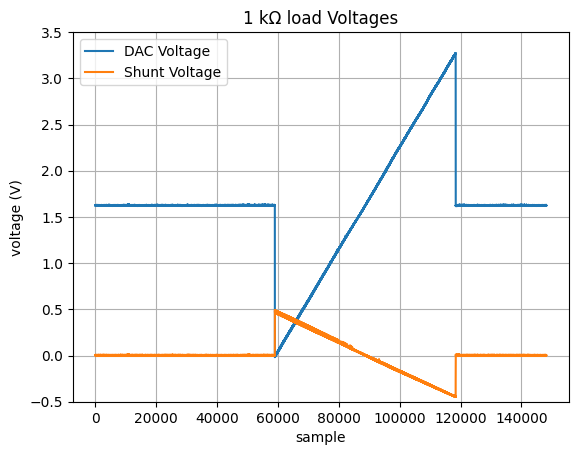

In [835]:
ax = data_1k_load.rename(columns={
    "dac_volts": "DAC Voltage",
    "shunt_volts": "Shunt Voltage"
}).plot(
    title="1 kΩ load Voltages",
    x="sample",
    y=["DAC Voltage", "Shunt Voltage"],
    grid=True,
    ylim=(-0.5, 3.5)
)

ax.set_xlabel("sample")
ax.set_ylabel("voltage (V)")

## 1.5 Signal transformation

- Ramp region extraction
- Stationary region removal
- Time alignment
- Sample count equalization


In [836]:
# Detecta região de rampa (ou, remove "regime em repouso") a partir de variação abrupta no DAC (indicando início e fim da rampa)

def extract_ramp_region(df, column, trigger_threshold):

    data = df.copy()

    diff = data[column].diff().abs()

    transition_points = diff[diff > trigger_threshold].index

    discarded_points = 512

    start = transition_points[0] + discarded_points
    end = transition_points[-1] - discarded_points

    return data.loc[start:end].copy()


def equalize_sample_count(*dfs):
    
    sample_count = min(len(df) for df in dfs)
    aligned_dfs = []

    for df in dfs:
        aligned_df = df.iloc[:sample_count].reset_index(drop=True).copy()
        aligned_df["sample"] = aligned_df.index
        aligned_dfs.append(aligned_df)

    return aligned_dfs

In [837]:
# Analisa apenas a coluna DAC pois o importante é descobrir o índice de início e fim da rampa.
# Os índices obtidos aplicam-se também às séries do shunt, para manter a fase entre sinais.

data_1k_load = extract_ramp_region(data_1k_load, column="dac_volts", trigger_threshold=0.5)
data_2k_load = extract_ramp_region(data_2k_load, column="dac_volts", trigger_threshold=0.5)
data_4k7_load = extract_ramp_region(data_4k7_load, column="dac_volts", trigger_threshold=0.5)

data_1k_load, data_2k_load, data_4k7_load = equalize_sample_count(data_1k_load, data_2k_load, data_4k7_load)

pd.DataFrame({"load": ["1k", "2k", "4k7"], "samples": [len(data_1k_load), len(data_2k_load), len(data_4k7_load)]})

,load,samples
0,1k,58386
1,2k,58386
2,4k7,58386


## 1.6 Feature engineering

- Current computation
- DAC data binning

Text(0, 0.5, 'current (mA)')

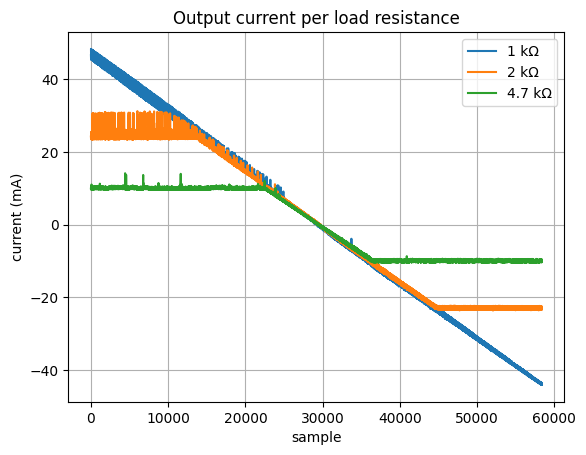

In [838]:
# A partir da tensão no shunt, calcula-se a corrente usando a lei de Ohm: I = V / R
# A corrente no shunt é a mesma da carga, dado que os dois estão em série.
# Multiplica-se por 1000 para converter de A para mA.

shunt_resistance = 10  # Ω

data_1k_load["current_mA"] = (data_1k_load["shunt_volts"] / shunt_resistance) * 1000
data_2k_load["current_mA"] = (data_2k_load["shunt_volts"] / shunt_resistance) * 1000
data_4k7_load["current_mA"] = (data_4k7_load["shunt_volts"] / shunt_resistance) * 1000

ax = data_1k_load.plot(x="sample", y="current_mA", grid=True, title="Output current per load resistance", label="1 kΩ")
data_2k_load.plot(x="sample", y="current_mA", ax=ax, label="2 kΩ", grid=True)
data_4k7_load.plot(x="sample", y="current_mA", ax=ax, label="4.7 kΩ", grid=True)

ax.set_xlabel("sample")
ax.set_ylabel("current (mA)")

## 1.7 Statistical aggregation

- Grouping by DAC bin
- Mean current estimation
- Pivot table generation


The DAC voltage was quantized using fixed-width quantization:

$$
V_{DAC,quantized} = \mathrm{round}\left(\frac{V_{DAC}}{\Delta V}\right) \cdot \Delta V
$$

where:

$$
\Delta V = 0.01\,V
$$


In [839]:
# Os valores de tensão do DAC foram agrupados em bins de 0,01 V,
# reduzindo a granularidade no domínio da tensão e 
# permitindo a agregação estatística de amostras em níveis equivalentes de DAC.

dac_step = 0.01  # passo de 10 mV para os bins de tensão do DAC

all_currents = pd.concat(
    [
        data_1k_load[["dac_volts", "current_mA"]].assign(load_value="1k"),
        data_2k_load[["dac_volts", "current_mA"]].assign(load_value="2k"),
        data_4k7_load[["dac_volts", "current_mA"]].assign(load_value="4k7"),
    ],
    ignore_index=True,
)

# O primeiro round() atribui cada valor de DAC ao bin mais próximo definido por dac_step.
# O round(2) final remove artefatos de ponto flutuante após multiplicar de volta pelo passo.
all_currents["dac_bin"] = ((all_currents["dac_volts"] / dac_step).round() * dac_step).round(2) #  fixed-width quantization


In [840]:
all_currents.head()

,dac_volts,current_mA,load_value,dac_bin
0,0.014687,46.626563,1k,0.01
1,0.014063,46.270313,1k,0.01
2,0.017812,46.409375,1k,0.02
3,0.014844,46.667187,1k,0.01
4,0.015156,46.270313,1k,0.02


In [841]:
all_currents.tail()

,dac_volts,current_mA,load_value,dac_bin
175153,3.245938,-10.323438,4k7,3.25
175154,3.240469,-9.884375,4k7,3.24
175155,3.240156,-9.953125,4k7,3.24
175156,3.242969,-10.279687,4k7,3.24
175157,3.244219,-10.156250,4k7,3.24


In [842]:
# Cria uma tabela de comparação indexada pelo bin de DAC.
# Cada carga vira uma coluna, e cada célula contém a corrente média
# das amostras que caíram no mesmo bin de DAC para aquela carga.
processed_current_data = all_currents.pivot_table(index="dac_bin", columns="load_value", values="current_mA", aggfunc="mean")
processed_current_data.head()

load_value,1k,2k,4k7
dac_bin,,,
0.01,45.911222,24.145882,9.911491
0.02,46.330384,24.310656,9.932422
0.03,46.122148,24.471661,9.954167
0.04,45.878822,24.520046,10.081883
0.05,45.556530,24.520062,10.074372


# EDA - Análise Exploratória dos Dados



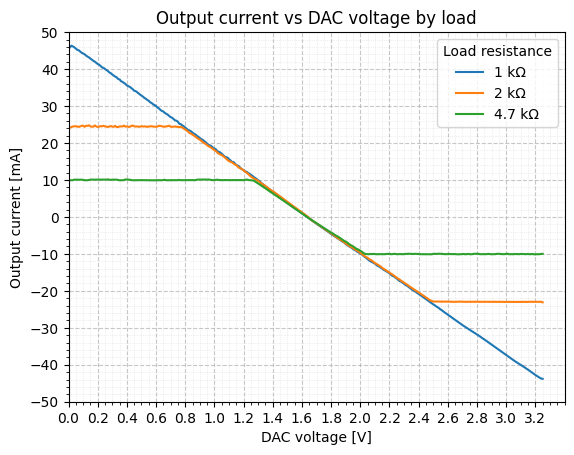

In [843]:
ax = processed_current_data.plot()

ax.set_xlim(0, 3.4)
ax.set_xticks([i / 10 for i in range(0, 34, 2)])

ax.set_ylim(-50, 50)
ax.set_yticks(range(-50, 51, 10))

ax.grid(True, which="major", linestyle="--", alpha=0.7)
ax.minorticks_on()
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Output current [mA]")
ax.set_title("Output current vs DAC voltage by load")
ax.legend(title="Load resistance")
ax.legend(["1 kΩ", "2 kΩ", "4.7 kΩ"], title="Load resistance")

## Compliance-limited region removal

The original `processed_current_data` is kept unchanged. The cells below create a new dataframe with the saturated regions removed from the 2 kΩ and 4.7 kΩ current signals.


In [844]:
# The FES output voltage is limited to approximately +/-48 V.
# Therefore, the theoretical saturation current is I = V / R.

fes_max_voltage = 48  # V

theoretical_saturation_current_mA = pd.Series(
    {
        "2k": (fes_max_voltage / 2000) * 1000,
        "4k7": (fes_max_voltage / 4700) * 1000,
    }
)

# A margin is used because measured saturation usually starts slightly before the ideal limit.
saturation_margin = 0.95

saturation_detection_limit_mA = theoretical_saturation_current_mA * saturation_margin
saturation_detection_limit_mA

2k     22.800000
4k7     9.702128
dtype: float64

In [845]:
linear_current_data = processed_current_data.copy()

# 1k does not saturate in this measurement, so it is intentionally kept unchanged.
linear_current_data["2k"] = linear_current_data["2k"].where(
    linear_current_data["2k"].abs() < saturation_detection_limit_mA["2k"]
)

linear_current_data["4k7"] = linear_current_data["4k7"].where(
    linear_current_data["4k7"].abs() < saturation_detection_limit_mA["4k7"]
)

pd.DataFrame(
    {
        "theoretical_saturation_current_mA": theoretical_saturation_current_mA,
        "detection_limit_mA": saturation_detection_limit_mA,
        "removed_points": processed_current_data[["2k", "4k7"]].notna().sum() - linear_current_data[["2k", "4k7"]].notna().sum(),
        "remaining_points": linear_current_data[["2k", "4k7"]].notna().sum(),
    }
)

,theoretical_saturation_current_mA,detection_limit_mA,removed_points,remaining_points
2k,24.000000,22.800000,158,167
4k7,10.212766,9.702128,251,74


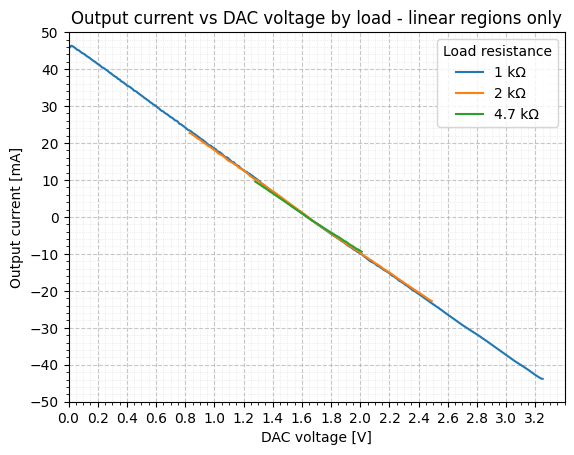

In [846]:
ax = linear_current_data.plot()

ax.set_xlim(0, 3.4)
ax.set_xticks([i / 10 for i in range(0, 34, 2)])

ax.set_ylim(-50, 50)
ax.set_yticks(range(-50, 51, 10))

ax.grid(True, which="major", linestyle="--", alpha=0.7)
ax.minorticks_on()
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Output current [mA]")
ax.set_title("Output current vs DAC voltage by load - linear regions only")
ax.legend(["1 kΩ", "2 kΩ", "4.7 kΩ"], title="Load resistance")


In [847]:
# =========================================================
# Descriptive statistics for the linear operating region
# =========================================================

linear_stats = linear_current_data.describe().T

linear_stats

,count,mean,std,min,25%,50%,75%,max
load_value,,,,,,,,
1k,325.0,0.788753,26.416914,-43.803125,-21.962662,0.131058,23.519614,46.330384
2k,167.0,-0.281045,13.343508,-22.740101,-11.722277,-0.668824,11.103038,22.686215
4k7,74.0,-0.111804,5.627913,-9.402746,-4.906152,-0.269278,4.713497,9.556291


In [848]:
# =========================================================
# Correlation between DAC voltage and output current
# =========================================================

correlation_summary = []

for load in ["1k", "2k", "4k7"]:
    data_load = linear_current_data[[load]].dropna().copy()
    data_load["dac_volts"] = data_load.index

    pearson = data_load["dac_volts"].corr(data_load[load], method="pearson")
    spearman = data_load["dac_volts"].corr(data_load[load], method="spearman")

    correlation_summary.append({
        "load": load,
        "pearson": pearson,
        "spearman": spearman,
    })

correlation_summary = pd.DataFrame(correlation_summary)

correlation_summary

,load,pearson,spearman
0,1k,-0.999909,-0.999999
1,2k,-0.999895,-1.000000
2,4k7,-0.999810,-1.000000


In [849]:
# =========================================================
# 1. Required libraries
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, LeaveOneGroupOut, cross_val_score

In [ ]:
# =========================================================
# 2. Compliance-limited region removal for all loads
# =========================================================

fes_max_voltage = 48  # V

load_resistance = pd.Series(
    {
        "1k": 1000,
        "2k": 2000,
        "4k7": 4700,
    }
)

saturation_margin = 0.95

saturation_detection_limit_mA = (fes_max_voltage / load_resistance) * 1000 * saturation_margin

linear_current_data = processed_current_data.copy()

for load in ["1k", "2k", "4k7"]:
    linear_current_data[load] = linear_current_data[load].where(
        linear_current_data[load].abs() < saturation_detection_limit_mA[load]
    )

saturation_summary = pd.DataFrame(
    {
        "load_resistance_ohm": load_resistance,
        "theoretical_saturation_current_mA": (fes_max_voltage / load_resistance) * 1000,
        "detection_limit_mA": saturation_detection_limit_mA,
        "processed_points": processed_current_data.notna().sum(),
        "linear_points": linear_current_data.notna().sum(),
    }
)

saturation_summary["removed_points"] = saturation_summary["processed_points"] - saturation_summary["linear_points"]

saturation_summary["removed_percent"] = (saturation_summary["removed_points"] / saturation_summary["processed_points"]) * 100

saturation_summary

,load_resistance_ohm,theoretical_saturation_current_mA,detection_limit_mA,processed_points,linear_points,removed_points,removed_percent
1k,1000,48.000000,45.600000,325,321,4,1.230769
2k,2000,24.000000,22.800000,325,167,158,48.615385
4k7,4700,10.212766,9.702128,325,74,251,77.230769


In [851]:
# =========================================================
# 3. Wide-to-long transformation
# =========================================================

processed_long = (
    processed_current_data
    .reset_index()
    .melt(
        id_vars="dac_bin",
        var_name="load",
        value_name="current_mA"
    )
    .dropna()
)

linear_long = (
    linear_current_data
    .reset_index()
    .melt(
        id_vars="dac_bin",
        var_name="load",
        value_name="current_mA"
    )
    .dropna()
)

processed_long.head(), linear_long.head()

(   dac_bin load  current_mA
 0     0.01   1k   45.911222
 1     0.02   1k   46.330384
 2     0.03   1k   46.122148
 3     0.04   1k   45.878822
 4     0.05   1k   45.556530,
    dac_bin load  current_mA
 4     0.05   1k   45.556530
 5     0.06   1k   45.219015
 6     0.07   1k   45.081353
 7     0.08   1k   44.765335
 8     0.09   1k   44.416022)

In [852]:
# =========================================================
# 4. Descriptive statistics
# =========================================================

descriptive_stats = linear_long.groupby("load")["current_mA"].describe()

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
load,,,,,,,,
1k,321.0,0.224618,26.089032,-43.803125,-22.286808,-0.431930,22.795141,45.556530
2k,167.0,-0.281045,13.343508,-22.740101,-11.722277,-0.668824,11.103038,22.686215
4k7,74.0,-0.111804,5.627913,-9.402746,-4.906152,-0.269278,4.713497,9.556291


In [853]:
# =========================================================
# 5. Correlation analysis: full data vs linear region
# =========================================================

correlation_summary = []

for dataset_name, dataset in [
    ("full_region", processed_long),
    ("linear_region", linear_long),
]:
    for load in ["1k", "2k", "4k7"]:
        data_load = dataset[dataset["load"] == load].copy()

        pearson_r, pearson_p = stats.pearsonr(
            data_load["dac_bin"],
            data_load["current_mA"]
        )

        spearman_r, spearman_p = stats.spearmanr(
            data_load["dac_bin"],
            data_load["current_mA"]
        )

        correlation_summary.append({
            "dataset": dataset_name,
            "load": load,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p,
        })

correlation_summary = pd.DataFrame(correlation_summary)

correlation_summary

,dataset,load,pearson_r,pearson_p,spearman_r,spearman_p
0,full_region,1k,-0.999909,0.000000e+00,-0.999999,0.000000e+00
1,full_region,2k,-0.975988,7.335758e-216,-0.984690,4.029354e-247
2,full_region,4k7,-0.926177,7.433494e-139,-0.899292,4.790004e-118
3,linear_region,1k,-0.999906,0.000000e+00,-1.000000,0.000000e+00
4,linear_region,2k,-0.999895,1.729580e-305,-1.000000,0.000000e+00
5,linear_region,4k7,-0.999810,6.640676e-125,-1.000000,0.000000e+00


In [854]:
# =========================================================
# 6. Linear regression by load
# Iout = a * Vdac + b
# =========================================================

regression_summary = []

for load in ["1k", "2k", "4k7"]:
    data_load = linear_long[linear_long["load"] == load].copy()

    x = data_load["dac_bin"].to_numpy()
    y = data_load["current_mA"].to_numpy()

    result = stats.linregress(x, y)

    y_pred = result.slope * x + result.intercept
    residuals = y - y_pred

    regression_summary.append({
        "load": load,
        "slope_mA_per_V": result.slope,
        "intercept_mA": result.intercept,
        "r_value": result.rvalue,
        "r_squared": result.rvalue ** 2,
        "p_value": result.pvalue,
        "slope_std_error": result.stderr,
        "MAE_mA": mean_absolute_error(y, y_pred),
        "RMSE_mA": mean_squared_error(y, y_pred) ** 0.5,
        "max_abs_error_mA": np.abs(residuals).max(),
        "samples": len(data_load),
    })

regression_summary = pd.DataFrame(regression_summary)

regression_summary

,load,slope_mA_per_V,intercept_mA,r_value,r_squared,p_value,slope_std_error,MAE_mA,RMSE_mA,max_abs_error_mA,samples
0,1k,-28.107842,46.602557,-0.999906,0.999813,0.000000e+00,0.021527,0.289268,0.356280,0.944804,321
1,2k,-27.593216,45.523693,-0.999895,0.999791,1.729580e-305,0.031073,0.159352,0.192416,0.443314,167
2,4k7,-26.164297,42.928464,-0.999810,0.999621,6.640676e-125,0.060078,0.094616,0.108888,0.259025,74


In [ ]:
# =========================================================
# 7. Global linear model for MCU control
# =========================================================

X = linear_long[["dac_bin"]].to_numpy()
y = linear_long["current_mA"].to_numpy()

global_model = LinearRegression()
global_model.fit(X, y)

linear_long["current_pred_mA"] = global_model.predict(X)
linear_long["residual_mA"] = linear_long["current_mA"] - linear_long["current_pred_mA"]

a_global = global_model.coef_[0]
b_global = global_model.intercept_

global_model_summary = pd.DataFrame(
    {
        "parameter": [
            "slope_mA_per_V",
            "intercept_mA",
            "MAE_mA",
            "RMSE_mA",
            "R2",
            "max_abs_error_mA",
            "samples",
        ],
        "value": [
            a_global,
            b_global,
            mean_absolute_error(y, linear_long["current_pred_mA"]),
            mean_squared_error(y, linear_long["current_pred_mA"]) ** 0.5,
            r2_score(y, linear_long["current_pred_mA"]),
            linear_long["residual_mA"].abs().max(),
            len(linear_long),
        ],
    }
)

print(f"Iout_mA = {a_global:.6f} * Vdac + {b_global:.6f}")
print(f"Vdac = (I_target_mA - ({b_global:.6f})) / {a_global:.6f}")

global_model_summary

Iout_mA = -28.024450 * Vdac + 46.335229
Vdac = (I_target_mA - (46.335229)) / -28.024450


,parameter,value
0,slope_mA_per_V,-28.024450
1,intercept_mA,46.335229
2,MAE_mA,0.329378
3,RMSE_mA,0.387655
4,R2,0.999662
5,max_abs_error_mA,0.941109
6,samples,562.000000


Text(0, 0.5, 'Residual [mA]')

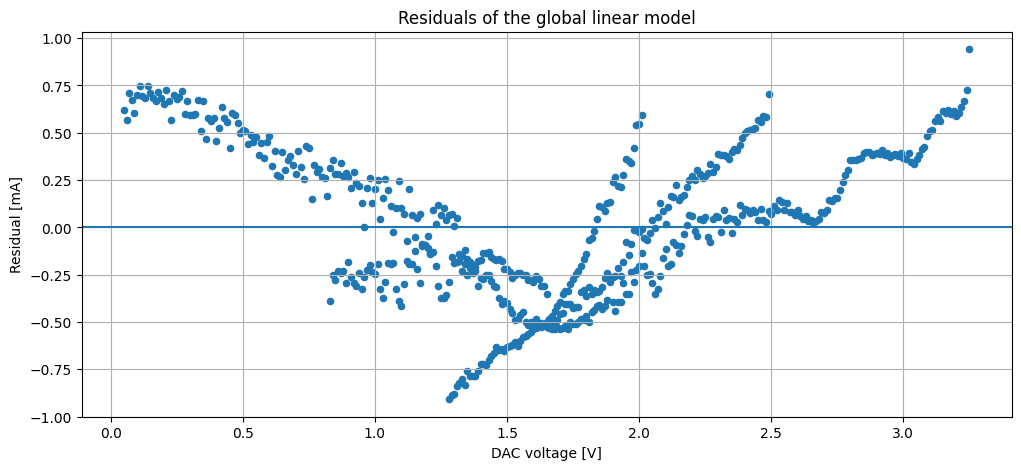

In [856]:
# =========================================================
# 8. Residual analysis
# =========================================================

ax = linear_long.plot(
    x="dac_bin",
    y="residual_mA",
    kind="scatter",
    figsize=(12, 5),
    grid=True,
    title="Residuals of the global linear model"
)

ax.axhline(0)
ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Residual [mA]")

In [857]:
# =========================================================
# 9. Load consistency analysis
# =========================================================

load_consistency = linear_current_data.copy()

load_consistency["spread_1k_2k_mA"] = (
    load_consistency["1k"] - load_consistency["2k"]
).abs()

load_consistency["spread_1k_4k7_mA"] = (
    load_consistency["1k"] - load_consistency["4k7"]
).abs()

load_consistency["spread_2k_4k7_mA"] = (
    load_consistency["2k"] - load_consistency["4k7"]
).abs()

consistency_summary = load_consistency[
    [
        "spread_1k_2k_mA",
        "spread_1k_4k7_mA",
        "spread_2k_4k7_mA",
    ]
].describe().T

consistency_summary

,count,mean,std,min,25%,50%,75%,max
load_value,,,,,,,,
spread_1k_2k_mA,167.0,0.264773,0.160384,0.003794,0.136627,0.227029,0.386884,0.702737
spread_1k_4k7_mA,74.0,0.386312,0.257382,0.002940,0.173668,0.395503,0.570956,0.972150
spread_2k_4k7_mA,74.0,0.382089,0.187704,0.012212,0.237945,0.404292,0.543318,0.730447


Text(0, 0.5, 'Absolute current difference [mA]')

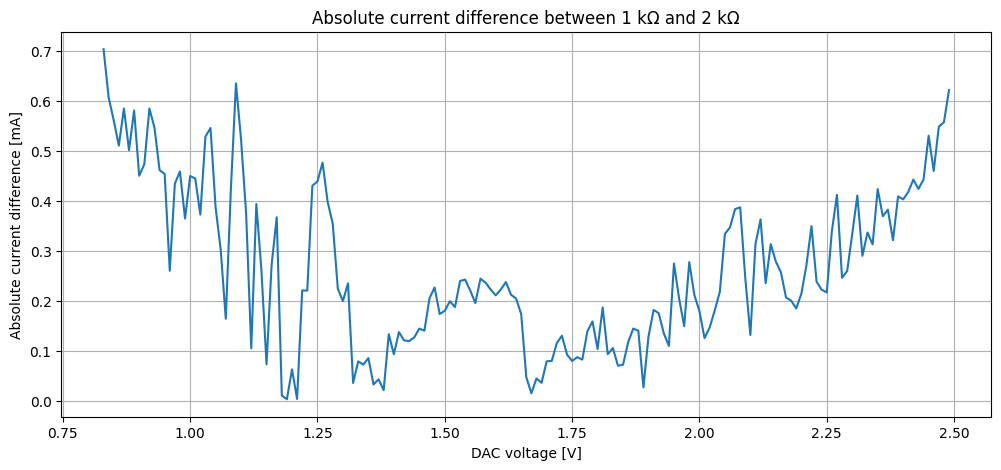

In [858]:
# =========================================================
# 10. Current spread plot
# =========================================================

ax = load_consistency["spread_1k_2k_mA"].plot(
    figsize=(12, 5),
    grid=True,
    title="Absolute current difference between 1 kΩ and 2 kΩ"
)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Absolute current difference [mA]")

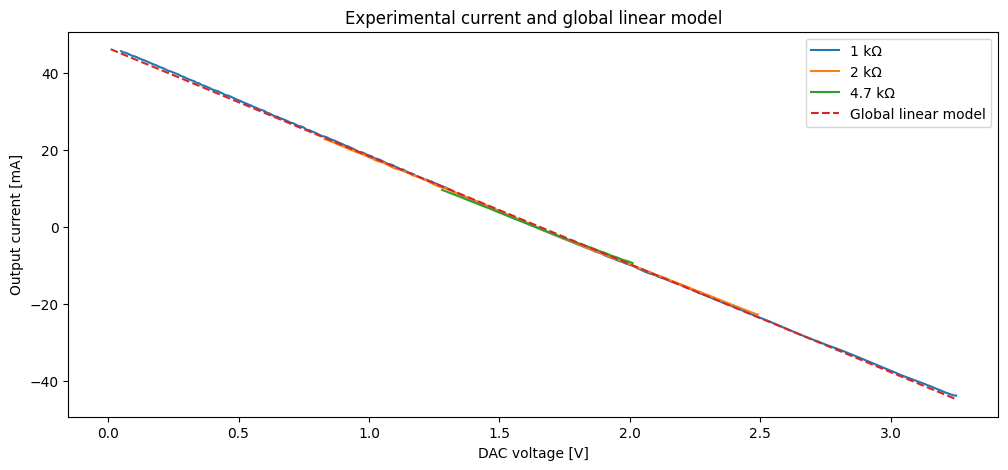

In [859]:
# =========================================================
# 11. Experimental data and global model
# =========================================================

model_curve = pd.DataFrame(index=linear_current_data.index)
model_curve["global_model"] = (
    a_global * model_curve.index + b_global
)

ax = linear_current_data.plot(
    figsize=(12, 5),
    grid=True,
    title="Experimental current and global linear model"
)

model_curve["global_model"].plot(
    ax=ax,
    linestyle="--",
    label="Global linear model"
)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Output current [mA]")
ax.legend(["1 kΩ", "2 kΩ", "4.7 kΩ", "Global linear model"])

In [860]:
# =========================================================
# 12. Cross-validation
# =========================================================

X = linear_long[["dac_bin"]].to_numpy()
y = linear_long["current_mA"].to_numpy()

model = LinearRegression()

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_rmse = -cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error"
)

cv_r2 = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring="r2"
)

cross_validation_summary = pd.DataFrame({
    "metric": ["RMSE_mean_mA", "RMSE_std_mA", "R2_mean", "R2_std"],
    "value": [
        cv_rmse.mean(),
        cv_rmse.std(),
        cv_r2.mean(),
        cv_r2.std(),
    ]
})

cross_validation_summary

,metric,value
0,RMSE_mean_mA,0.388892
1,RMSE_std_mA,0.015900
2,R2_mean,0.999655
3,R2_std,0.000044


In [861]:
# =========================================================
# 13. Leave-one-load-out validation
# =========================================================

X = linear_long[["dac_bin"]].to_numpy()
y = linear_long["current_mA"].to_numpy()
groups = linear_long["load"].to_numpy()

logo = LeaveOneGroupOut()

logo_results = []

for train_index, test_index in logo.split(X, y, groups):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    test_load = np.unique(groups[test_index])[0]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    logo_results.append({
        "test_load": test_load,
        "slope_mA_per_V": model.coef_[0],
        "intercept_mA": model.intercept_,
        "MAE_mA": mean_absolute_error(y_test, y_pred),
        "RMSE_mA": mean_squared_error(y_test, y_pred) ** 0.5,
        "R2": r2_score(y_test, y_pred),
    })

logo_summary = pd.DataFrame(logo_results)

logo_summary

,test_load,slope_mA_per_V,intercept_mA,MAE_mA,RMSE_mA,R2
0,1k,-27.474431,45.251934,0.553370,0.751510,0.999168
1,2k,-28.083809,46.473571,0.306141,0.333641,0.999371
2,4k7,-28.045110,46.421978,0.511311,0.576987,0.989345
